# Spam Detection: Naive Bayes vs SVM

**Student Name:** Jidapa Angsutti  
**Date:** 02/26/2026

In this project, you'll:
1. Load a spam email dataset
2. Train a Naive Bayes classifier
3. Train an SVM classifier
4. Compare the results

<small><i>Note</i>: This project was created with the assistance of AI</small>

---

## Step 1: Import Libraries and Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load the dataset
df = pd.read_csv("../data/spam_data.csv")

# Display first few rows
df.head()

,word_free,word_money,word_winner,word_click,word_urgent,num_exclamation,num_dollar,num_capitals,email_length,has_link,is_spam
0,0.116603,0.081405,0.248621,0.107026,0.084280,0.162809,0.042277,0.240659,101.836546,0.296066,0
1,0.150017,0.202468,0.071720,0.227412,0.228002,0.093779,0.123205,0.062907,90.571442,0.193681,0
2,0.009429,0.190923,0.094307,0.152571,0.272270,0.074788,0.123115,0.226665,130.369345,0.023094,0
3,0.085727,0.129830,0.205633,0.099737,0.016976,0.112176,0.283335,0.192520,98.526674,0.189685,0
4,0.050113,0.050286,0.011001,0.220921,0.199141,0.142389,0.253251,0.241701,96.637459,0.260481,0


## Step 2: Preprocessing the Data
* Clean the data
* Split the data into training and test sets.
* Feature Scaling

In [3]:
df.isna().sum()

word_free          0
word_money         0
word_winner        0
word_click         0
word_urgent        0
num_exclamation    0
num_dollar         0
num_capitals       0
email_length       0
has_link           0
is_spam            0
dtype: int64

In [5]:
# Split the data using a random state of 42 for reproducibility
X = df.drop('is_spam', axis=1)
Y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

## Step 3: Train Naive Bayes Classifier

In [6]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [7]:
nb_preds = nb_model.predict(X_test)

Display your confusion matrix and your classification report.

[[164   0]
 [  0 136]]


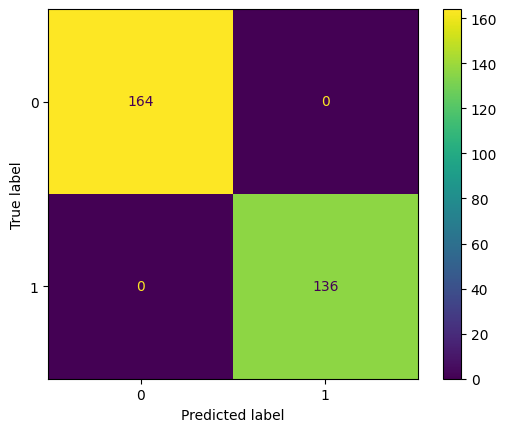

In [8]:
cm = confusion_matrix(y_test, nb_preds, labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

In [9]:
report = classification_report(y_test, nb_preds)
print(report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00       136

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Step 4: Train k-Nearest Neighbors Classifier

In [10]:
n = len(df)
k = np.sqrt(n)
k

np.float64(31.622776601683793)

In [ ]:
k = 31
knn_class = KNeighborsClassifier(n_neighbors=k, metric='cosine')
knn_class.fit(X_train, y_train)
knn_preds = knn_class.predict(X_test)

Display your confusion matrix and classification report.

[[164   0]
 [  0 136]]


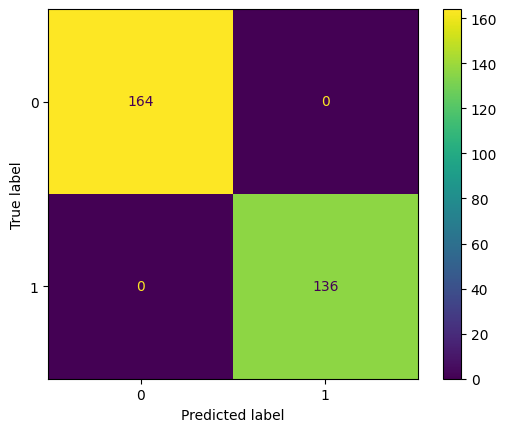

In [12]:
cm = confusion_matrix(y_test, knn_preds, labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

In [14]:
report = classification_report(y_test, knn_preds)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00       136

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Step 5: Train SVM Classifier

In [15]:
polykernel_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1, gamma="scale"))
])

polykernel_svc.fit(X_train, y_train)
svc_preds = polykernel_svc.predict(X_test)

Display your confusion matrix and your classification report.

[[164   0]
 [  0 136]]


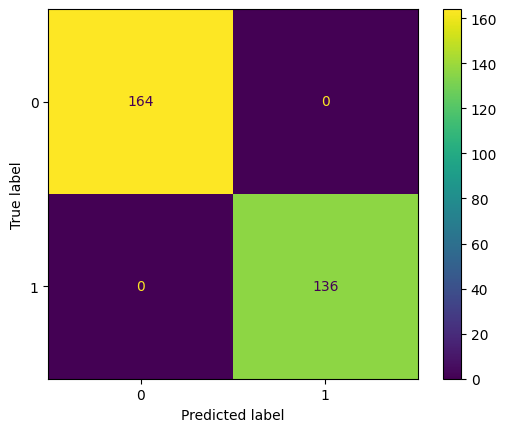

In [17]:
cm = confusion_matrix(y_test, svc_preds, labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

In [18]:
report = classification_report(y_test, svc_preds)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       164
           1       1.00      1.00      1.00       136

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Step 6: Compare the Models
* Create graphs that compare model results
* Make calculations to compare model results

Due to data being very classifiable and having 100% accuracy, I'll use a 'worse' model from the KNN Model: Euclidean metric, for the sake of discussing metrics

[[164   0]
 [ 33 103]]


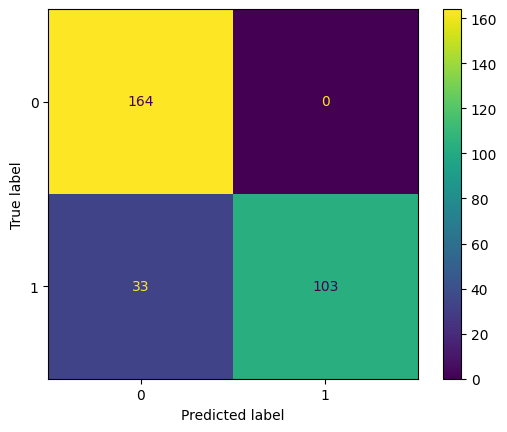

In [19]:
k = 31
knn_class = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn_class.fit(X_train, y_train)
y_pred = knn_class.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

In [20]:
data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'] * 3,
    'Model': (['Naive Bayes'] * 4) + (['k-NN'] * 4) + (['SVM'] * 4),
    'Score': [
        # Naive Bayes scores
        accuracy_score(y_test, nb_preds), precision_score(y_test, nb_preds),
        recall_score(y_test, nb_preds), f1_score(y_test, nb_preds),
        # k-NN scores
        accuracy_score(y_test, knn_preds), precision_score(y_test, knn_preds),
        recall_score(y_test, knn_preds), f1_score(y_test, knn_preds),
        # SVM scores
        accuracy_score(y_test, svc_preds), precision_score(y_test, svc_preds),
        recall_score(y_test, svc_preds), f1_score(y_test, svc_preds)
    ]
}

# 2. Convert to a DataFrame
df_results = pd.DataFrame(data)
df_results

,Metric,Model,Score
0,Accuracy,Naive Bayes,1.0
1,Precision,Naive Bayes,1.0
2,Recall,Naive Bayes,1.0
3,F1-Score,Naive Bayes,1.0
4,Accuracy,k-NN,1.0
5,Precision,k-NN,1.0
6,Recall,k-NN,1.0
7,F1-Score,k-NN,1.0
8,Accuracy,SVM,1.0
9,Precision,SVM,1.0


Discuss the results of your comparison.

They're all perfect, because the datapoints are so cleanly separated. That being said, when I ran with random_state=1 (see Project_Classification1.ipynb file), kNN did have 1 incorrect prediction (big deal). It's probably due to "distance-based" nature of KNN, which doesn't do as well when the 2 classes are rectangles separated by a straight boundary. It's further amplified by using euclidean distance

## Step 7: Answer Discussion Questions

Based on your results, answer the following questions:

### Question 1: Which model performed better overall? Why do you think so?

**Your Answer:**

SVM and Naive Bayes performed better overall; albeit just by a little (due to KNN having 1 data point wrong). SVM is the most intuitive to understand why it works; because SVM works by having a straight line and margins as separator, it makes sense that it performs so well in a dataset in which the 2 classes are separated by straight boundaries. As for Naive Bayes, I would guess that it worked in a similar way with the probabilities, though it doesn't work intuitively visually like SVM does  

---

### Question 2: What is the difference between accuracy and precision? Which is more important for spam detection?

**Your Answer:**

Accuracy is the % of correct predictions, while precision penalizes you for making false positives. Precision is more important for spam decision; a poor/low precision score means you're making a lot of false positives. In terms of spam detection, you might wrongly flag an email as spam and thus hide it from the user, when in reality it was an important email. That'd be pretty bad  

---

### Question 3: When would you choose Naive Bayes over kNN or SVM in a real-world application?

**Your Answer:**

Naive Bayes is incredibly fast, so it can handle large, real-world datasets well. In a sense, it's an iterative process that can "train as it goes" or as it gets more data, and does not need large datasets to start with to be useful (though still able to scale well with increasing dataset sizes). It would also be most effective if we can assume feature independence.  

---

### Question 4: What are the key assumptions of Naive Bayes? Do you think they hold true for this spam detection problem?

**Your Answer:**

Naive Bayes assumes that all features are independent of each other. In terms of spam detection, I would say this doesn't stand. The presence of the word "winner" and "money" could truly have a relationship (winners get rewards, rewards are usually money). I guess the model still performed well, however, since the datapoints are so uniform/cleanly separated.  

---

### Question 5: How did you determine your value for $k$ in the kNN model?

**Your Answer:**
I square-rooted _n_, which gave something about 31. 31 happened to already be prime, so I kept it.  

---

## Summary

In this project, you:
- ✅ Loaded and split a spam detection dataset
- ✅ Trained a Naive Bayes classifier
- ✅ Trained an SVM classifier  
- ✅ Compared both models using multiple metrics
- ✅ Analyzed the results

**Key Takeaways:**
1. Different algorithms can produce different results on the same data
2. Multiple metrics (accuracy, precision, recall) give a complete picture
3. Both Naive Bayes and SVM are effective for classification tasks
4. The choice of algorithm depends on the specific requirements of your problem